In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def F(a,y):
  res = np.zeros(3)
  res[0] = a[0]*(y[1]-y[0])
  res[1] = ((a[2]-a[0])*y[0] - y[0]*y[2] + a[2]*y[1])
  res[2] = (y[0]*y[1] - a[1]*y[2])

  return res



def mapa(a,x,h):
  '''são as constantes de nossos a,b e c que irão determinar as condições de nosso problema
     x,y,z é um vetor com 3 entradas do nosso mapa.

     retorna x_new,y_new,z_new'''
  k1 = F(a,x)
  k2 = F(a,x + k1*(h/2))
  k3 = F(a,x + k2*(h/2))
  k4 = F(a,x + h*k3)
  x = x + h*(k1 + 2*k2 + 2*k3 + k4)/6

  return x

def dist(x,y):
  d = np.max(np.abs(x-y))
  return d

def norma(x):
  d = np.max(np.abs(x))
  return d

In [2]:
def fecho_orbita(a,x,h,epsilon):
  '''fecho == False ==> Limitada
  fecho == True ==> Divergiu'''
  fecho = False
  T_trans = 20
  N = int(T_trans/h)

  T_real = 40
  M = int(T_real/h)

  sol = np.zeros([M,len(x)])
  tran = np.copy(x)# condição inicial do transiente

  for i in range(1,N):
    tran = mapa(a,tran,h) # aqui atualizamos o transiente em 10^5 passos de tempo
  sol[0,:] = tran # definimos o inicio de nossa solução
  for i in range(1,M):
    sol[i,:] = mapa(a,sol[i-1,:],h) #gravamos toda a trajetória evoluindo com RK44
    if dist(sol[0,:],sol[i,:]) < epsilon: # verificamos se a orbita 'fecha' ou não
      break
    elif norma(sol[i,:]) > 10**4 : # verificamos se diverge ou não
      fecho = True
      break
  return fecho,sol

In [4]:
def max_orbita_x(a_params, fecho, sol):
  # 'a_params' deve ser um array 1D de parâmetros (por exemplo, 4 elementos).
  # Concatenaremos esses parâmetros com o valor x_max.
  result_rows = []

  if fecho == True:
    # Se a órbita divergiu, x_max é tipicamente representado como 0.0 ou um valor especial.
    # Concatena os 'a_params' (4 elementos) com um único escalar (0.0)
    # para formar uma linha de 5 elementos.
    row_to_append = np.concatenate((a_params, [0.0]))
    result_rows.append(row_to_append)
  else:
    # Prepara a solução para análise (tornando-a cíclica para detecção de picos)
    an_sol = np.zeros([len(sol)+2,len(sol[-1,:])])
    an_sol[0,:] = sol[-1,:]
    an_sol[1:-1,:] = sol[:,:]
    an_sol[-1,:] = sol[0,:]

    # Encontra máximos locais no primeiro componente (coordenada x, índice 0)
    for i in range(20,len(sol)-20): # Intervalo ajustado para detecção estável
      if an_sol[i-1,0] < an_sol[i,0] and an_sol[i,0] > an_sol[i+1,0]:
        # Concatena 'a_params' com o valor x_max encontrado para formar uma linha de 5 elementos.
        row_to_append = np.concatenate((a_params, [an_sol[i,0]]))
        result_rows.append(row_to_append)

  # Retorna um array das linhas coletadas. Se nenhum máximo foi encontrado, retorna um array vazio
  # com o número correto de colunas (5 neste caso) para manter a consistência da forma.
  if not result_rows:
      return np.empty((0, len(sol[-1,:]) + 1), dtype=float)
  else:
      return np.array(result_rows, dtype=float)


def max_orbita_y(a,b,c,fecho,sol):
  bif_val = np.array([[0,0,0,0]])
  if fecho == True:
    bif_val = np.append([[a,b,c,1]],bif_val,axis = 0)
  else:
    an_sol = np.zeros([len(sol)+2,4])
    an_sol[0,:] = sol[-1,:]
    an_sol[1:-1,:] = sol[:,:]
    an_sol[-1,:] = sol[0,:]
    for i in range(20,len(sol)-20):
      if an_sol[i-1,1] < an_sol[i,1] and an_sol[i,1] > an_sol[i+1,1]:
        bif_val = np.append([[a,b,c,an_sol[i,1]]],bif_val,axis = 0)
  bif_val = np.delete(bif_val,-1,0)
  return bif_val

#Chen-Ueta

In [ ]:
# --- Parte principal do script da célula original ---

a = np.array([40.0, 1.8, 33]) # Parâmetros iniciais para k_perp, f, rho, ell

h = 0.001 # passo do método de integração
db = 0.001# passo do parâmetro a ser variado (por exemplo, f ou b/c)
epsilon = 10**-5 # tolerância para verificação de fechamento de órbita

# Inicializa 'bif' como um array vazio com 5 colunas:
# 4 parâmetros de 'a' (k_perp, f, rho, ell) e 1 para x_max.
# Isso garante que futuras anexações mantenham uma forma consistente.
bif1 = np.empty((0, len(a) + 1), dtype=float)



# Assumindo que 'bs' se destina a iterar sobre o segundo parâmetro de 'a' (f)
# com base no código original, onde 'b' era tipicamente variado em outros exemplos.
# Aqui 'bs' contém valores de 2 a 5.0.
f_values = np.arange(2.5, 4.5 + db, db) # Usa 2.0 e 5.0 para consistência de float

for f_val in f_values:
  current_a_params = np.copy(a) # Faz uma cópia para evitar modificar o 'a' original no lugar
  current_a_params[1] = f_val # Define o parâmetro 'f' (a[1]) para o valor da iteração atual

  # Condição inicial para x, y, z, theta.
  # Garante que x[1] seja calculado usando current_a_params[0]
  x_initial1 = np.array([-0.1,0.5, -0.6])#(-0.1,0.6,1)


  valor1, sol1 = fecho_orbita(current_a_params, x_initial1, h, epsilon)


  # Chama o max_orbita_x (definido localmente) com os parâmetros atuais
  current_bif_points1 = max_orbita_x(current_a_params, valor1, sol1)


  # Anexa os resultados da iteração atual ao array 'bif' principal.
  if current_bif_points1.size > 0 : # Anexa apenas se max_orbita_x retornou algum ponto
    bif1 = np.append(bif1, current_bif_points1, axis = 0)


# O array 'bif' agora contém linhas, onde cada linha é:
# [k_perp, f, rho, ell, x_max]
# Para plotar um diagrama de bifurcação de 'f' vs 'x_max', você usaria:
# plt.scatter(bif[:,1], bif[:,4], s = 1)

Text(0, 0.5, 'x_max')

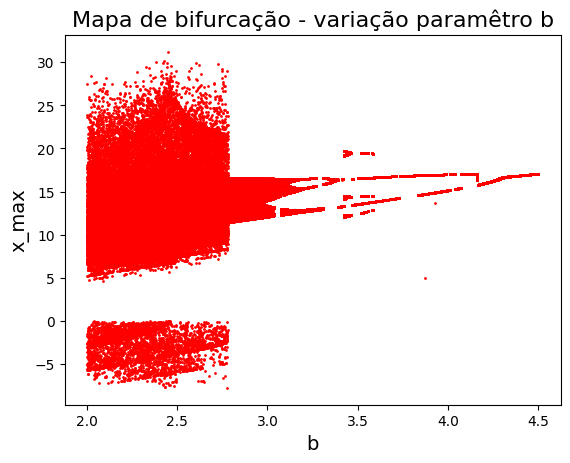

In [ ]:
plt.scatter(bif1[:,1],bif1[:,3],s = 1, color='r' )
plt.title('Mapa de bifurcação - variação paramêtro b',fontsize = 16)
plt.xlabel('b', fontsize = 14)
plt.ylabel('x_max', fontsize = 14)





#Chen-Ueta (teste de multiestabilidade)

In [ ]:

# --- Parte principal do script da célula original ---

a = np.array([40.0, 1.8, 33]) # Parâmetros iniciais para k_perp, f, rho, ell

h = 0.001 # passo do método de integração
db = 0.001# passo do parâmetro a ser variado (por exemplo, f ou b/c)
epsilon = 10**-5 # tolerância para verificação de fechamento de órbita

# Inicializa 'bif' como um array vazio com 5 colunas:
# 4 parâmetros de 'a' (k_perp, f, rho, ell) e 1 para x_max.
# Isso garante que futuras anexações mantenham uma forma consistente.
bif2 = np.empty((0, len(a) + 1), dtype=float)
bif3 = np.empty((0, len(a) + 1), dtype=float)
bif4 = np.empty((0, len(a) + 1), dtype=float)



# Assumindo que 'bs' se destina a iterar sobre o segundo parâmetro de 'a' (f)
# com base no código original, onde 'b' era tipicamente variado em outros exemplos.
# Aqui 'bs' contém valores de 2 a 5.0.
f_values_ida = np.arange(2.5, 4.5 + db, db) # Usa 2.0 e 5.0 para consistência de float
f_values_volta = np.arange(4.5+db, 2.5, -db)
f_values_ida3 = np.arange(3.5, 4.5 + db, db) # para achar o periodo 3
f_values_volta3 = np.arange(3.5, 2.5, -db)


#condição inicial
x_initial1 = np.array([-0.7,0.3, -0.6])

########################################################################################
########################## Experimento IDA #############################################
########################################################################################

for f_val in f_values_ida:
  current_a_params = np.copy(a) # Faz uma cópia para evitar modificar o 'a' original no lugar
  current_a_params[1] = f_val # Define o parâmetro 'f' (a[1]) para o valor da iteração atual

  # Condição inicial para x, y, z, theta.
  # Garante que x[1] seja calculado usando current_a_params[0]


  valor1, sol1 = fecho_orbita(current_a_params, x_initial1, h, epsilon)

  #a próxima condição inicial é o ponto final da orbita anterior
  x_initial1 = sol1[-1,:]



  # Chama o max_orbita_x (definido localmente) com os parâmetros atuais
  current_bif_points1 = max_orbita_x(current_a_params, valor1, sol1)


  # Anexa os resultados da iteração atual ao array 'bif' principal.
  if current_bif_points1.size > 0 : # Anexa apenas se max_orbita_x retornou algum ponto
    bif2 = np.append(bif2, current_bif_points1, axis = 0)


########################################################################################
########################## Experimento VOLTA ###########################################
########################################################################################

for f_val in f_values_volta:
  current_a_params = np.copy(a) # Faz uma cópia para evitar modificar o 'a' original no lugar
  current_a_params[1] = f_val # Define o parâmetro 'f' (a[1]) para o valor da iteração atual

  # Condição inicial para x, y, z, theta.
  # Garante que x[1] seja calculado usando current_a_params[0]


  valor2, sol2 = fecho_orbita(current_a_params, x_initial1, h, epsilon)

  x_initial1 = sol2[-1,:]

  # Chama o max_orbita_x (definido localmente) com os parâmetros atuais
  current_bif_points2 = max_orbita_x(current_a_params, valor2, sol2)

  # Anexa os resultados da iteração atual ao array 'bif' principal.
  if current_bif_points2.size > 0: # Anexa apenas se max_orbita_x retornou algum ponto
    bif3 = np.append(bif3, current_bif_points2, axis = 0)


########################################################################################
########################## Experimento PERÍODO 3 #######################################
########################################################################################

x_initial1 = [-0.1,0.6, 1]
for f_val in f_values_ida3:
  current_a_params = np.copy(a) # Faz uma cópia para evitar modificar o 'a' original no lugar
  current_a_params[1] = f_val # Define o parâmetro 'f' (a[1]) para o valor da iteração atual

  # Condição inicial para x, y, z, theta.
  # Garante que x[1] seja calculado usando current_a_params[0]


  valor3, sol3 = fecho_orbita(current_a_params, x_initial1, h, epsilon)

  #a próxima condição inicial é o ponto final da orbita anterior
  x_initial1 = sol3[-1,:]



  # Chama o max_orbita_x (definido localmente) com os parâmetros atuais
  current_bif_points3 = max_orbita_x(current_a_params, valor3, sol3)


  # Anexa os resultados da iteração atual ao array 'bif' principal.
  if current_bif_points3.size > 0 : # Anexa apenas se max_orbita_x retornou algum ponto
    bif4 = np.append(bif4, current_bif_points3, axis = 0)


x_initial1 = np.array([-0.1,0.6, 1])

for f_val in f_values_volta3:
  current_a_params = np.copy(a) # Faz uma cópia para evitar modificar o 'a' original no lugar
  current_a_params[1] = f_val # Define o parâmetro 'f' (a[1]) para o valor da iteração atual

  # Condição inicial para x, y, z, theta.
  # Garante que x[1] seja calculado usando current_a_params[0]


  valor3, sol3 = fecho_orbita(current_a_params, x_initial1, h, epsilon)

  x_initial1 = sol3[-1,:]

  # Chama o max_orbita_x (definido localmente) com os parâmetros atuais
  current_bif_points3 = max_orbita_x(current_a_params, valor3, sol3)

  # Anexa os resultados da iteração atual ao array 'bif' principal.
  if current_bif_points3.size > 0: # Anexa apenas se max_orbita_x retornou algum ponto
    bif4 = np.append(bif4, current_bif_points3, axis = 0)

# O array 'bif' agora contém linhas, onde cada linha é:
# [k_perp, f, rho, ell, x_max]
# Para plotar um diagrama de bifurcação de 'f' vs 'x_max', você usaria:
# plt.scatter(bif[:,1], bif[:,4], s = 1)

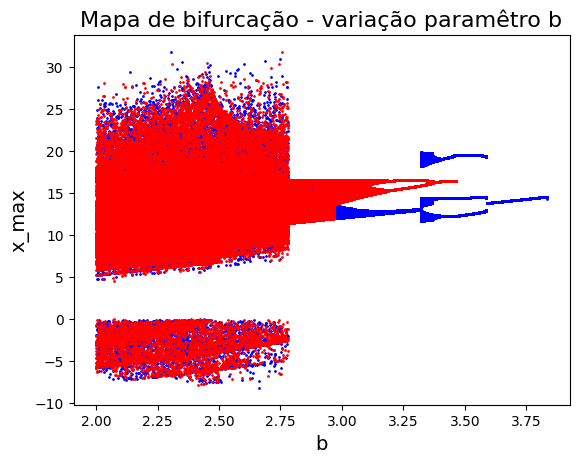

In [ ]:
plt.title('Mapa de bifurcação - variação paramêtro b',fontsize = 16)
plt.xlabel('b', fontsize = 14)
plt.ylabel('x_max', fontsize = 14)

plt.scatter(bif4[:,1],bif4[:,3],s = 1, color='b' )
plt.scatter(bif2[:,1],bif2[:,3],s = 1, color='r' )
plt.scatter(bif3[:,1],bif3[:,3],s = 1, color = 'g')



#Chen-Ueta (encontrar o periodo 3)

condição inicial ([-0.1,0.5, -0.6])
passo RK4 0.01

Teremos uma solução metaestável de período 5

Mas, tomando passo RK4 0.005 temos a região estável de período 1, e para passo 0.001 temos outra órbita também de período 1, mas simétrica  como pode ser visto abaixo


In [6]:
def fecho_orbita_outro(a,x,h,epsilon):
  '''fecho == False ==> Limitada
  fecho == True ==> Divergiu'''
  fecho = False
  T_trans = 30
  N = int(T_trans/h)

  T_real = 80
  M = int(T_real/h)

  sol = np.zeros([M,len(x)])
  tran = np.copy(x)# condição inicial do transiente

  for i in range(1,N):
    tran = mapa(a,tran,h) # aqui atualizamos o transiente em 10^5 passos de tempo
  sol[0,:] = tran # definimos o inicio de nossa solução
  for i in range(1,M):
    sol[i,:] = mapa(a,sol[i-1,:],h) #gravamos toda a trajetória evoluindo com RK44
    if dist(sol[0,:],sol[i,:]) < epsilon: # verificamos se a orbita 'fecha' ou não
      break
    elif norma(sol[i,:]) > 10**4 : # verificamos se diverge ou não
      fecho = True
      break
  return fecho,sol

In [8]:
h1 = 0.01
h2 = 0.005
h3 = 0.0001
epsilon = 10**-5
x_initial1 = np.array([-0.1,0.5, -0.6])
current_a_params = np.array([40.0, 3.621, 33])


valor1, sol1 = fecho_orbita(current_a_params, x_initial1, h1, epsilon)
valor2, sol2 = fecho_orbita(current_a_params, x_initial1, h2, epsilon)
valor3, sol3 = fecho_orbita(current_a_params, x_initial1, h3, epsilon)


valor1_outro, sol1_outro = fecho_orbita_outro(current_a_params, sol1[-1,:], h3, epsilon)

In [10]:
print(sol1[-1,:])

[-12.41583528 -11.86578167  39.49211319]


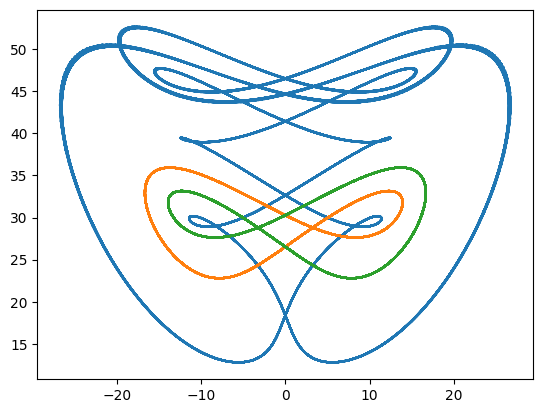

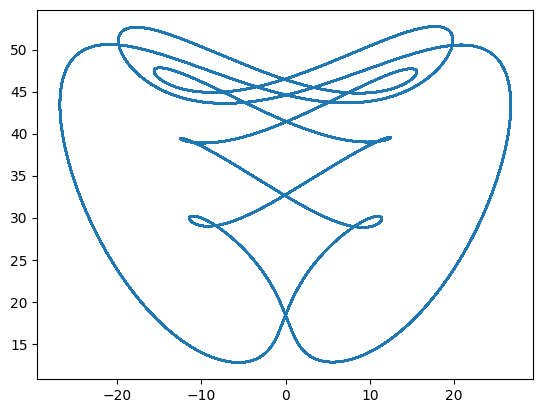

In [9]:
plt.plot(sol1[:,0],sol1[:,2])
plt.plot(sol2[:,0],sol2[:,2])
plt.plot(sol3[:,0],sol3[:,2])

plt.show()

plt.plot(sol1_outro[:,0],sol1_outro[:,2])

plt.show()


#Chen-Ueta (Tomar posições random)

In [ ]:
a = np.array([40.0, 1.8, 33]) # Parâmetros iniciais para k_perp, f, rho, ell

h = 0.001 # passo do método de integração
db = 0.001# passo do parâmetro a ser variado (por exemplo, f ou b/c)
epsilon = 10**-5 # tolerância para verificação de fechamento de órbita

# Inicializa 'bif' como um array vazio com 5 colunas:
# 4 parâmetros de 'a' (k_perp, f, rho, ell) e 1 para x_max.
# Isso garante que futuras anexações mantenham uma forma consistente.

n_elementos = 10

bif_g = {i: np.empty((0, len(a) + 1)) for i in range(n_elementos)}

# Assumindo que 'bs' se destina a iterar sobre o segundo parâmetro de 'a' (f)
# com base no código original, onde 'b' era tipicamente variado em outros exemplos.
# Aqui 'bs' contém valores de 2 a 5.0.
f_values_ida = np.arange(3, 4 + db, db) # Usa 2.0 e 5.0 para consistência de float



#condição inicial
x_initial = np.random.uniform(-1,1,[n_elementos,3])
print(x_initial)

for i in range(n_elementos):
  x_initial1 = x_initial[i,:]
  for f_val in f_values_ida:
    current_a_params = np.copy(a) # Faz uma cópia para evitar modificar o 'a' original no lugar
    current_a_params[1] = f_val # Define o parâmetro 'f' (a[1]) para o valor da iteração atual

    # Condição inicial para x, y, z, theta.
    # Garante que x[1] seja calculado usando current_a_params[0]


    valor5, sol5 = fecho_orbita(current_a_params, x_initial1, h, epsilon)

    #a próxima condição inicial é o ponto final da orbita anterior
    x_initial1 = sol5[-1,:]



    # Chama o max_orbita_x (definido localmente) com os parâmetros atuais
    current_bif_points5 = max_orbita_x(current_a_params, valor5, sol5)


    # Anexa os resultados da iteração atual ao array 'bif' principal.
    if current_bif_points5.size > 0 : # Anexa apenas se max_orbita_x retornou algum ponto
      bif_g[i] = np.append(bif_g[i], current_bif_points5, axis = 0)





# O array 'bif' agora contém linhas, onde cada linha é:
# [k_perp, f, rho, ell, x_max]
# Para plotar um diagrama de bifurcação de 'f' vs 'x_max', você usaria:
# plt.scatter(bif[:,1], bif[:,4], s = 1)

[[ 0.15403499 -0.42090584 -0.80894007]
 [-0.21770497  0.45009482 -0.22469724]
 [-0.69002142  0.68448864  0.63528311]
 [-0.8110879  -0.15881615 -0.21026473]
 [ 0.59034256 -0.89273169 -0.99921971]
 [-0.76909212 -0.89343676 -0.60431909]
 [-0.26547278  0.65006962  0.81849049]
 [-0.93420389 -0.1568068   0.95996156]
 [-0.91834401  0.67044959  0.77181417]
 [ 0.07403993  0.44525566  0.27885711]]


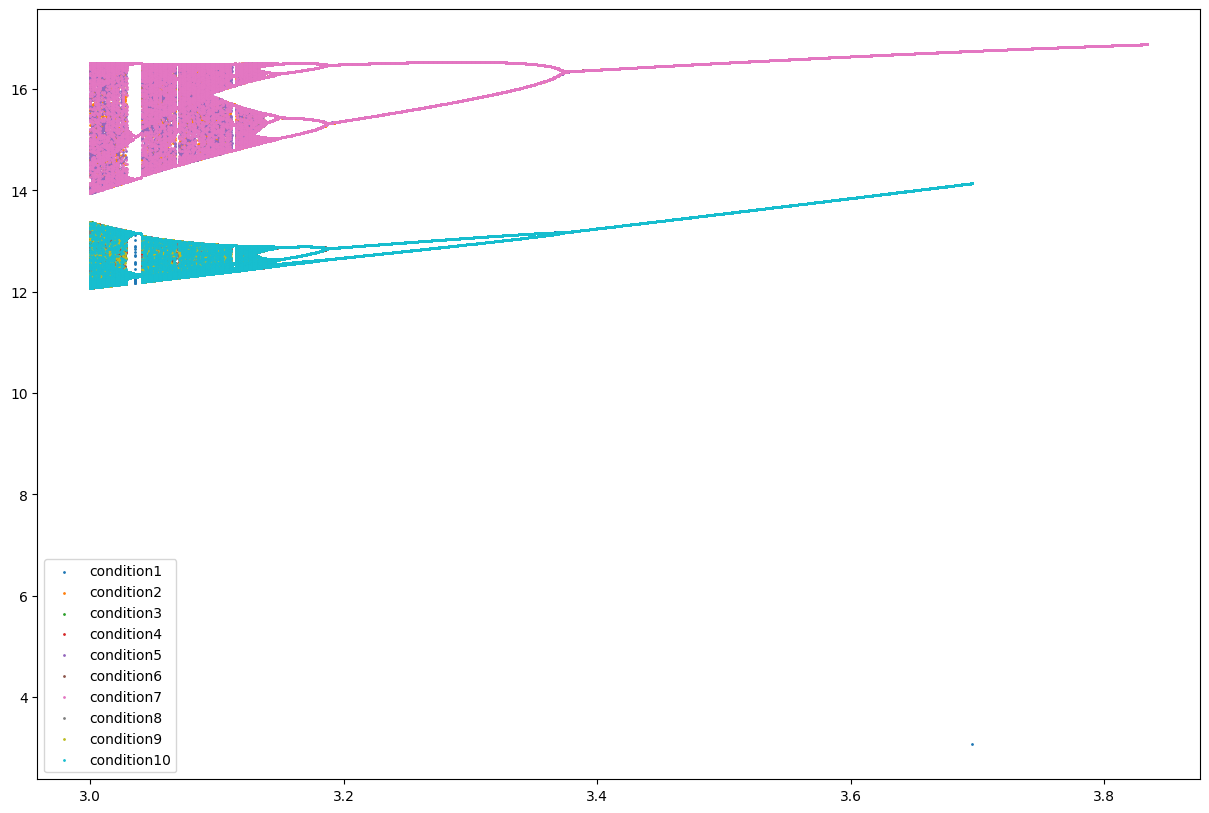

In [ ]:


plt.figure(figsize=(15, 10))
cores = plt.cm.tab10(np.linspace(0, 1, n_elementos))
for i, cor in enumerate(cores):
    dados = bif_g[i]
    if dados.size > 0:
        # dados[:, 1] seria o parâmetro f e dados[:, 4] o x_max
        plt.scatter(dados[:, 1], dados[:, 3], color=cor, s=1, label = 'condition'+str(i+1))

plt.legend()